# Experiment 7 - Grayscale Texture & Stats

**Pipeline preprocessing:** Baseline (grayscale + resize) ditambah ekstraksi fitur histogram intensitas keabuan (16 bin) dan statistik orde pertama (mean, std dev, skewness, kurtosis) tanpa menggunakan LBP.

## Setup

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Berjalan di Google Colab. Menyiapkan environment...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    REPO_DIR = '/content/cloud-classification'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/Vuxyn/cloud-classification.git
    else:
        !git -C {REPO_DIR} pull
        
    %cd {REPO_DIR}/notebooks
    
    ZIP_PATH = '/content/drive/MyDrive/GCD-zip.zip'
    EXTRACT_DIR = '/content/GCD-zip'
    
    if os.path.exists(ZIP_PATH):
        if not os.path.exists(EXTRACT_DIR):
            print(f"Mengekstrak {ZIP_PATH} ke {EXTRACT_DIR}...")
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print("Ekstraksi selesai!")
        else:
            print(f"Dataset sudah diekstrak di {EXTRACT_DIR}")
    else:
        print(f"Peringatan: File zip {ZIP_PATH} tidak ditemukan di Google Drive Anda.")
        print("Pastikan nama file zip di Drive utama adalah 'GCD-zip.zip'.")

    # Cek apakah runtime menggunakan GPU
    import subprocess
    try:
        subprocess.check_output('nvidia-smi')
        print("GPU NVIDIA terdeteksi, menginstall cupy...")
        !pip install cupy-cuda12x python-dotenv gdown scipy
    except Exception:
        print("GPU tidak aktif. Menjalankan menggunakan CPU.")
        !pip install python-dotenv gdown scipy

In [2]:
import sys
sys.path.append('..')  # supaya src/ bisa diimport dari notebooks/

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from src.loader import get_dataset_root, load_dataset
from src.image_processing import *

EXPERIMENT_NAME = "experiment7"


CuPy tidak tersedia - fallback ke NumPy (CPU)


## Data Loading

In [3]:
DATASET_ROOT = get_dataset_root()
images, labels, filenames = load_dataset(DATASET_ROOT, target_size=(256, 256), color=False)
print(f"Dataset loaded: {len(images)} gambar grayscale, {len(set(labels))} kelas")

Environment: Lokal
DATASET_ROOT dari .env: D:\INFORMATICS\SEMESTER 4\IMAGE PROCESSING\Praktikum\Project\GCD


Loading cumulus:   0%|          | 0/775 [00:00<?, ?it/s]

Loading cumulus:   6%|▌         | 44/775 [00:00<00:01, 433.82it/s]

Loading cumulus:  13%|█▎        | 100/775 [00:00<00:01, 503.94it/s]

Loading cumulus:  20%|██        | 156/775 [00:00<00:01, 529.34it/s]

...

Loading mixed:  73%|███████▎  | 441/607 [00:01<00:00, 446.69it/s]

Loading mixed:  81%|████████  | 490/607 [00:01<00:00, 457.46it/s]

Loading mixed:  88%|████████▊ | 537/607 [00:01<00:00, 446.22it/s]

Loading mixed:  96%|█████████▌| 583/607 [00:01<00:00, 443.44it/s]

Dataset loaded: 19000 gambar, 7 kelas, ukuran=(256, 256)
Dataset loaded: 19000 gambar grayscale, 7 kelas


## Dataset Visualization & Distribution

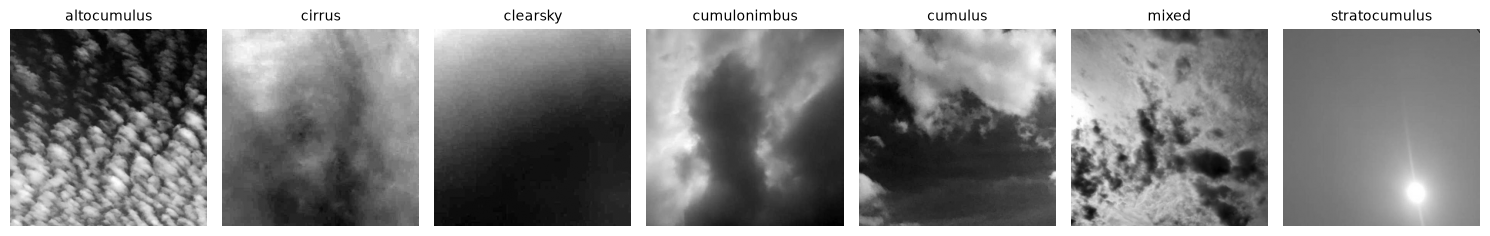

C:\Users\Mahesa\AppData\Local\Temp\ipykernel_40748\492372970.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d')


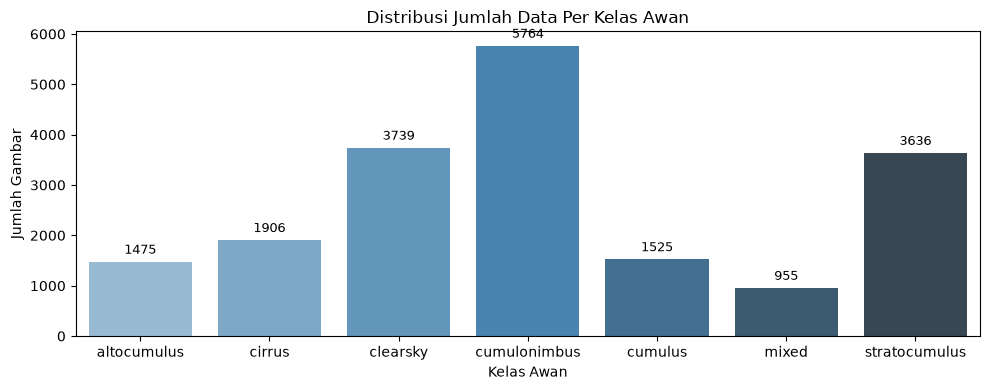

In [4]:
# Tampilkan contoh gambar untuk setiap kelas
unique_labels = sorted(list(set(labels)))
fig, axes = plt.subplots(1, len(unique_labels), figsize=(15, 3))
for i, label in enumerate(unique_labels):
    idx = np.where(labels == label)[0][0]
    img = images[idx]
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
    else:
        axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label, fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Tampilkan bar chart distribusi kelas
plt.figure(figsize=(10, 4))
label_counts = pd.Series(labels).value_counts().sort_index()
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d')
plt.title('Distribusi Jumlah Data Per Kelas Awan')
plt.xlabel('Kelas Awan')
plt.ylabel('Jumlah Gambar')
for i, count in enumerate(label_counts.values):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
# ================================================================
# EDIT BAGIAN INI untuk mengubah pipeline preprocessing
# ================================================================
PIPELINE = [
    lambda img: to_grayscale(img),
]


def apply_pipeline(image: np.ndarray, pipeline: list) -> np.ndarray:
    for fn in pipeline:
        image = fn(image)
    return image

In [6]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

def process_one(img):
    return apply_pipeline(img, PIPELINE)

if not PIPELINE:
    images_preprocessed = images.copy()
else:
    if USING_GPU:
        print("Menggunakan ThreadPoolExecutor (GPU aktif)...")
        with ThreadPoolExecutor(max_workers=4) as executor:
            images_preprocessed = list(tqdm(
                executor.map(process_one, images),
                total=len(images),
                desc="Preprocessing"
            ))
    else:
        print("Menggunakan Pemrosesan Sekuensial CPU...")
        images_preprocessed = [process_one(img) for img in tqdm(images, desc="Preprocessing")]
        
    images_preprocessed = np.array(images_preprocessed)

Menggunakan Pemrosesan Sekuensial CPU...


Preprocessing:   0%|          | 0/19000 [00:00<?, ?it/s]

Preprocessing: 100%|██████████| 19000/19000 [00:00<00:00, 857675.49it/s]

## Feature Extraction - Grayscale Histogram & Statistics

In [7]:
histograms, means, stds, skews, kurtoses = extract_grayscale_stats(images_preprocessed)

## Feature Extraction - GLCM Texture

In [8]:
def glcm(image, angle):
    if angle == 0:
        angles = [0]
    elif angle == 45:
        angles = [np.pi / 4]
    elif angle == 90:
        angles = [np.pi / 2]
    elif angle == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan 0, 45, 90, atau 135.")

    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)


def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]


def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]


def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]


def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]


def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]


def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]


def entropyGlcm(matriks):
    return entropy(matriks.ravel())


In [9]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in tqdm(range(len(images_preprocessed)), desc="Extracting GLCM features"):
    g0 = glcm(images_preprocessed[i], 0)
    g45 = glcm(images_preprocessed[i], 45)
    g90 = glcm(images_preprocessed[i], 90)
    g135 = glcm(images_preprocessed[i], 135)
    
    Kontras0.append(contrast(g0))
    Kontras45.append(contrast(g45))
    Kontras90.append(contrast(g90))
    Kontras135.append(contrast(g135))
    
    dissimilarity0.append(dissimilarity(g0))
    dissimilarity45.append(dissimilarity(g45))
    dissimilarity90.append(dissimilarity(g90))
    dissimilarity135.append(dissimilarity(g135))
    
    homogenity0.append(homogenity(g0))
    homogenity45.append(homogenity(g45))
    homogenity90.append(homogenity(g90))
    homogenity135.append(homogenity(g135))
    
    entropy0.append(entropyGlcm(g0))
    entropy45.append(entropyGlcm(g45))
    entropy90.append(entropyGlcm(g90))
    entropy135.append(entropyGlcm(g135))
    
    ASM0.append(ASM(g0))
    ASM45.append(ASM(g45))
    ASM90.append(ASM(g90))
    ASM135.append(ASM(g135))
    
    energy0.append(energy(g0))
    energy45.append(energy(g45))
    energy90.append(energy(g90))
    energy135.append(energy(g135))
    
    correlation0.append(correlation(g0))
    correlation45.append(correlation(g45))
    correlation90.append(correlation(g90))
    correlation135.append(correlation(g135))

Extracting GLCM features:   0%|          | 0/19000 [00:00<?, ?it/s]

Extracting GLCM features:   0%|          | 4/19000 [00:00<08:06, 39.03it/s]

Extracting GLCM features:   0%|          | 10/19000 [00:00<06:14, 50.77it/s]

Extracting GLCM features:   0%|          | 16/19000 [00:00<06:04, 52.08it/s]

Extracting GLCM features:   0%|          | 22/19000 [00:00<06:00, 52.68it/s]

...

Extracting GLCM features: 100%|█████████▉| 18978/19000 [05:12<00:00, 58.09it/s]

Extracting GLCM features: 100%|█████████▉| 18984/19000 [05:12<00:00, 58.40it/s]

Extracting GLCM features: 100%|█████████▉| 18991/19000 [05:12<00:00, 60.06it/s]

Extracting GLCM features: 100%|█████████▉| 18998/19000 [05:12<00:00, 61.14it/s]

Extracting GLCM features: 100%|██████████| 19000/19000 [05:12<00:00, 60.80it/s]

In [10]:
dataTable = {
    'Filename': filenames,
    'Label': labels,
    # Fitur GLCM
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
    # Statistik Keabuan Orde Pertama
    'Gray_Mean': means, 'Gray_Std': stds,
    'Gray_Skew': skews, 'Gray_Kurt': kurtoses
}

# Tambahkan histogram keabuan 16 bin ke table
for b in range(16):
    dataTable[f'Gray_Hist_Bin_{b}'] = histograms[:, b]

df = pd.DataFrame(dataTable)
csv_path = f'hasil_ekstraksi_{EXPERIMENT_NAME}.csv'
df.to_csv(csv_path, index=False)
print(f'Fitur gabungan tersimpan ke {csv_path}')
df.head()

Fitur gabungan tersimpan ke hasil_ekstraksi_experiment7.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Gray_Hist_Bin_6,Gray_Hist_Bin_7,Gray_Hist_Bin_8,Gray_Hist_Bin_9,Gray_Hist_Bin_10,Gray_Hist_Bin_11,Gray_Hist_Bin_12,Gray_Hist_Bin_13,Gray_Hist_Bin_14,Gray_Hist_Bin_15
0,1_cumulus_000001.jpg,cumulus,4.266238,6.879308,5.158180,9.419608,0.597426,0.515852,0.579409,0.495421,...,0.000008,0.012082,0.020010,0.008336,0.006186,0.007939,0.005760,0.002175,0.000003,0.000000
1,1_cumulus_000002.jpg,cumulus,3.036504,6.479585,5.062316,8.304129,0.648462,0.541533,0.619315,0.537407,...,0.001694,0.020264,0.011356,0.003250,0.002982,0.004457,0.005059,0.007312,0.005684,0.000443
2,1_cumulus_000003.jpg,cumulus,9.158333,18.900515,10.695282,17.573595,0.527355,0.448897,0.531987,0.442087,...,0.016761,0.014311,0.004938,0.003093,0.003123,0.003247,0.002704,0.003510,0.003659,0.000154
3,1_cumulus_000004.jpg,cumulus,5.909681,11.468558,6.869930,11.881261,0.615510,0.520967,0.596584,0.513569,...,0.021894,0.011566,0.005079,0.003640,0.002706,0.002934,0.002425,0.004356,0.005047,0.000000
4,1_cumulus_000005.jpg,cumulus,3.622748,9.158339,6.721844,9.899008,0.650936,0.495088,0.552258,0.500163,...,0.001370,0.004457,0.007899,0.011701,0.005535,0.004569,0.004782,0.009298,0.008772,0.000000


## Feature Selection

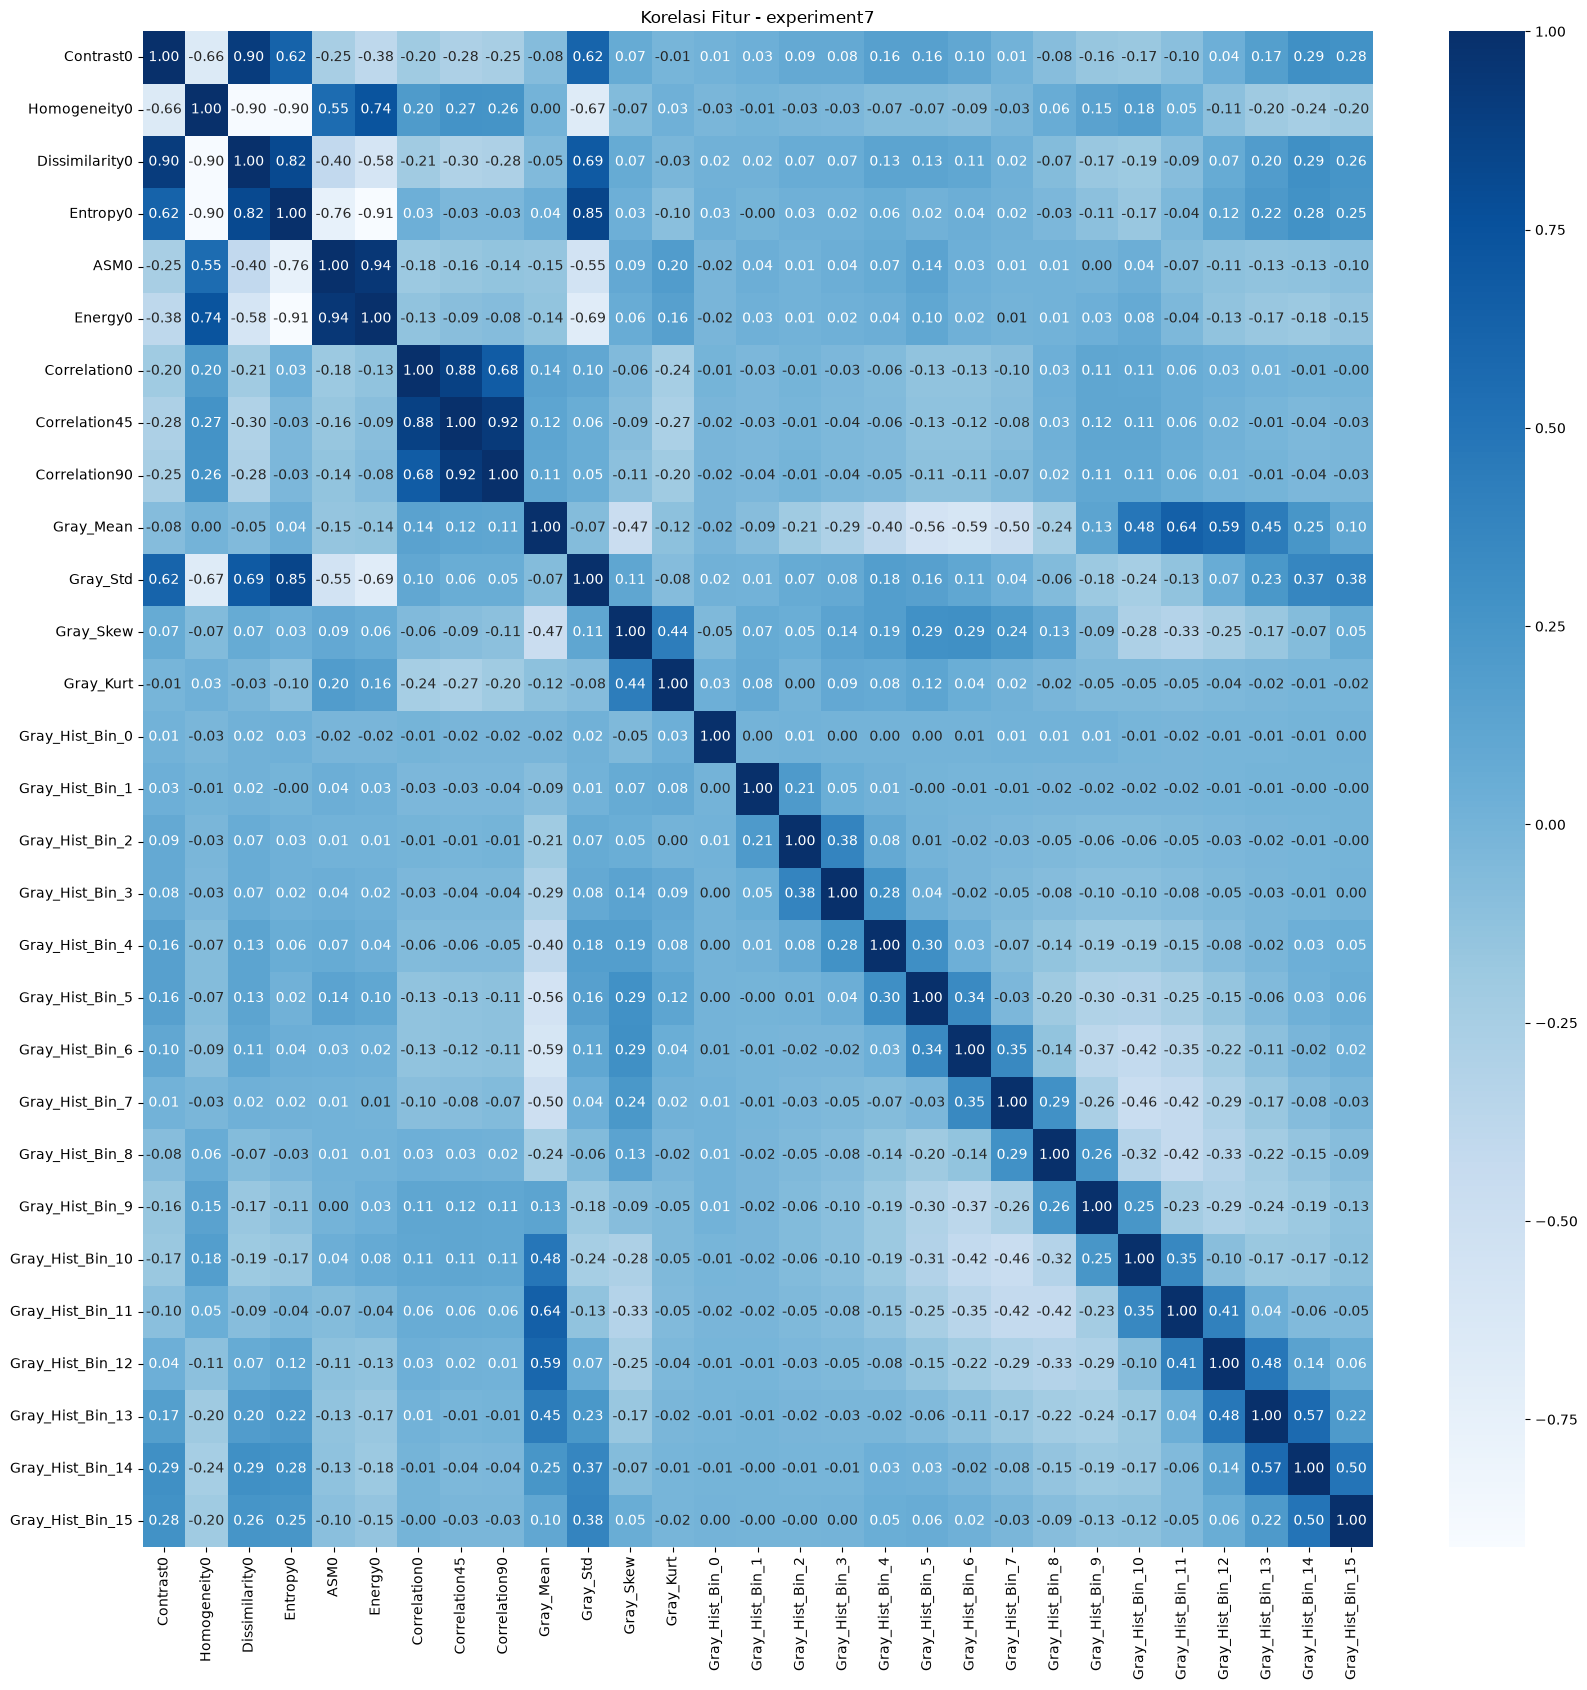

Selected 29 features out of 48


,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Correlation45,Correlation90,Gray_Mean,...,Gray_Hist_Bin_6,Gray_Hist_Bin_7,Gray_Hist_Bin_8,Gray_Hist_Bin_9,Gray_Hist_Bin_10,Gray_Hist_Bin_11,Gray_Hist_Bin_12,Gray_Hist_Bin_13,Gray_Hist_Bin_14,Gray_Hist_Bin_15
0,4.266238,0.597426,1.217310,6.324128,0.003997,0.063220,0.997258,0.995578,0.996684,152.172638,...,0.000008,0.012082,0.020010,0.008336,0.006186,0.007939,0.005760,0.002175,0.000003,0.000000
1,3.036504,0.648462,0.990548,6.298019,0.004444,0.066660,0.999136,0.998160,0.998561,159.263382,...,0.001694,0.020264,0.011356,0.003250,0.002982,0.004457,0.005059,0.007312,0.005684,0.000443
2,9.158333,0.527355,1.755025,6.779807,0.003476,0.058954,0.997547,0.994926,0.997128,135.717773,...,0.016761,0.014311,0.004938,0.003093,0.003123,0.003247,0.002704,0.003510,0.003659,0.000154
3,5.909681,0.615510,1.303738,6.480208,0.004193,0.064751,0.998506,0.997098,0.998262,139.495468,...,0.021894,0.011566,0.005079,0.003640,0.002706,0.002934,0.002425,0.004356,0.005047,0.000000
4,3.622748,0.650936,1.044041,6.503792,0.003266,0.057151,0.998989,0.997443,0.998125,169.903732,...,0.001370,0.004457,0.007899,0.011701,0.005535,0.004569,0.004782,0.009298,0.008772,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18995,3.336504,0.669241,0.970450,6.082961,0.004301,0.065581,0.997189,0.993552,0.996556,169.943909,...,0.000000,0.002411,0.009810,0.010733,0.007966,0.017183,0.013292,0.001095,0.000010,0.000000
18996,5.178370,0.537875,1.414246,6.683481,0.002044,0.045215,0.997002,0.995741,0.997277,169.019974,...,0.000758,0.007045,0.006476,0.006186,0.014619,0.013392,0.007616,0.004861,0.001546,0.000000
18997,3.384161,0.603304,1.114063,6.674435,0.002161,0.046483,0.998833,0.996458,0.997073,157.869476,...,0.005887,0.010856,0.010165,0.009377,0.005416,0.006398,0.006686,0.004044,0.002509,0.001159
18998,6.433379,0.571700,1.381694,6.770346,0.002244,0.047373,0.997779,0.990218,0.990708,153.443481,...,0.006750,0.012494,0.011943,0.008198,0.006209,0.005066,0.004002,0.004028,0.002377,0.001433


In [11]:
correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
selection_feature = []
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = df.drop(columns=['Label', 'Filename']).columns[columns]
x_new = df[select]
y = df['Label']

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Korelasi Fitur - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()

print(f"Selected {len(select)} features out of {correlation_matrix.shape[0]}")
x_new

## Splitting Data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)

(15200, 29)
(3800, 29)


## Feature Normalization

In [13]:
mean_train = X_train.mean()
std_train = X_train.std()
X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train

## Modeling

In [14]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
knn = KNeighborsClassifier(n_neighbors=5)

In [15]:
# Train + evaluate RF
print('------Random Forest - Training Set------')
rf.fit(X_train_norm, y_train)
y_pred_rf_train = rf.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_rf_train)

print('\n------Random Forest - Testing Set------')
y_pred_rf_test = rf.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_rf_test)

# Train + evaluate SVM
print('\n------SVM - Training Set------')
svm.fit(X_train_norm, y_train)
y_pred_svm_train = svm.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_svm_train)

print('\n------SVM - Testing Set------')
y_pred_svm_test = svm.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_svm_test)

# Train + evaluate KNN
print('\n------KNN - Training Set------')
knn.fit(X_train_norm, y_train)
y_pred_knn_train = knn.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_knn_train)

print('\n------KNN - Testing Set------')
y_pred_knn_test = knn.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_knn_test)

------Random Forest - Training Set------


               precision    recall  f1-score   support

  altocumulus       1.00      1.00      1.00      1180
       cirrus       0.99      1.00      0.99      1525
     clearsky       0.98      1.00      0.99      2991
 cumulonimbus       1.00      0.95      0.97      4611
      cumulus       0.98      1.00      0.99      1220
        mixed       0.99      1.00      0.99       764
stratocumulus       0.95      1.00      0.97      2909

     accuracy                           0.98     15200
    macro avg       0.98      0.99      0.99     15200
 weighted avg       0.98      0.98      0.98     15200

[[1180    0    0    0    0    0    0]
 [   0 1525    0    0    0    0    0]
 [   0    0 2987    0    0    0    4]
 [   5   16   55 4367   19    8  141]
 [   0    0    0    0 1220    0    0]
 [   0    0    0    0    0  764    0]
 [   0    0    5    1    0    0 2903]]
Accuracy: 0.9832894736842105

------Random Forest - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.65      0.65      0.65       295
       cirrus       0.42      0.43      0.42       381
     clearsky       0.79      0.87      0.83       748
 cumulonimbus       0.66      0.57      0.61      1153
      cumulus       0.77      0.76      0.77       305
        mixed       0.50      0.46      0.48       191
stratocumulus       0.61      0.70      0.65       727

     accuracy                           0.66      3800
    macro avg       0.63      0.63      0.63      3800
 weighted avg       0.65      0.66      0.65      3800

[[192  26   0  33  17  14  13]
 [ 31 163  36  95  13  16  27]
 [  1  21 653  36   2   0  35]
 [ 27 117  83 653  18  28 227]
 [ 11  16   1  15 233  27   2]
 [ 23  27   1  18  17  88  17]
 [ 10  20  48 134   1   4 510]]
Accuracy: 0.6557894736842105

------SVM - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.70      0.72      0.71      1180
       cirrus       0.39      0.43      0.41      1525
     clearsky       0.75      0.86      0.80      2991
 cumulonimbus       0.64      0.41      0.50      4611
      cumulus       0.86      0.75      0.80      1220
        mixed       0.46      0.63      0.53       764
stratocumulus       0.57      0.74      0.64      2909

     accuracy                           0.63     15200
    macro avg       0.62      0.65      0.63     15200
 weighted avg       0.64      0.63      0.62     15200

[[ 848   74    3   93   21   95   46]
 [ 109  653  217  277   26  103  140]
 [   6  109 2561  169    2    4  140]
 [ 112  623  439 1895   54  198 1290]
 [  30   81    3   35  916  144   11]
 [  59   54    7   84   46  479   35]
 [  54   84  196  392    0   23 2160]]
Accuracy: 0.6257894736842106

------SVM - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.67      0.67      0.67       295
       cirrus       0.39      0.45      0.42       381
     clearsky       0.73      0.85      0.79       748
 cumulonimbus       0.64      0.41      0.50      1153
      cumulus       0.83      0.71      0.76       305
        mixed       0.39      0.49      0.43       191
stratocumulus       0.55      0.73      0.63       727

     accuracy                           0.61      3800
    macro avg       0.60      0.62      0.60      3800
 weighted avg       0.62      0.61      0.60      3800

[[197  25   1  28   9  22  13]
 [ 28 173  46  65  11  26  32]
 [  1  27 636  44   1   1  38]
 [ 28 152 117 471  11  49 325]
 [ 10  19   3  10 216  44   3]
 [ 21  21   5  21  12  94  17]
 [ 11  26  58  98   0   6 528]]
Accuracy: 0.6092105263157894

------KNN - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.73      0.73      0.73      1180
       cirrus       0.56      0.49      0.52      1525
     clearsky       0.79      0.91      0.84      2991
 cumulonimbus       0.67      0.75      0.70      4611
      cumulus       0.85      0.76      0.80      1220
        mixed       0.72      0.36      0.48       764
stratocumulus       0.73      0.66      0.69      2909

     accuracy                           0.72     15200
    macro avg       0.72      0.66      0.68     15200
 weighted avg       0.71      0.72      0.71     15200

[[ 866   58    8  145   31   37   35]
 [  81  744  179  407   16   17   81]
 [   8   70 2711  132    1    0   69]
 [  56  243  322 3445   40   19  486]
 [  42   79   19  115  923   34    8]
 [ 104   52   14  221   75  273   25]
 [  29   74  181  705    0    1 1919]]
Accuracy: 0.7158552631578947

------KNN - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.61      0.57      0.59       295
       cirrus       0.37      0.33      0.35       381
     clearsky       0.72      0.85      0.78       748
 cumulonimbus       0.58      0.66      0.62      1153
      cumulus       0.82      0.70      0.75       305
        mixed       0.44      0.23      0.30       191
stratocumulus       0.66      0.56      0.61       727

     accuracy                           0.62      3800
    macro avg       0.60      0.56      0.57      3800
 weighted avg       0.62      0.62      0.61      3800

[[169  23   3  54  14  21  11]
 [ 27 124  51 138  11  10  20]
 [  0  29 638  50   1   1  29]
 [ 25  89 117 764   6  11 141]
 [ 17  21   7  39 212   9   0]
 [ 26  21   5  66  15  44  14]
 [ 11  26  62 216   0   3 409]]
Accuracy: 0.6210526315789474


## Evaluation - Confusion Matrix

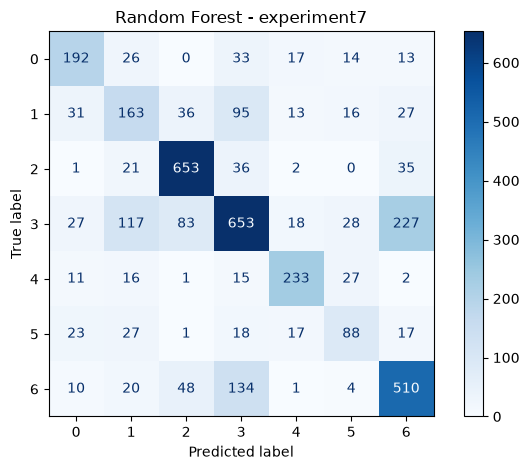

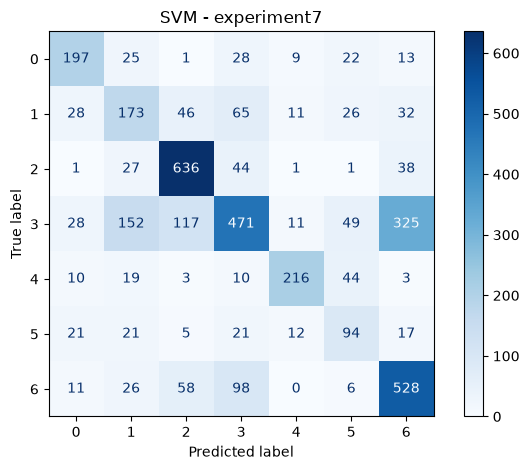

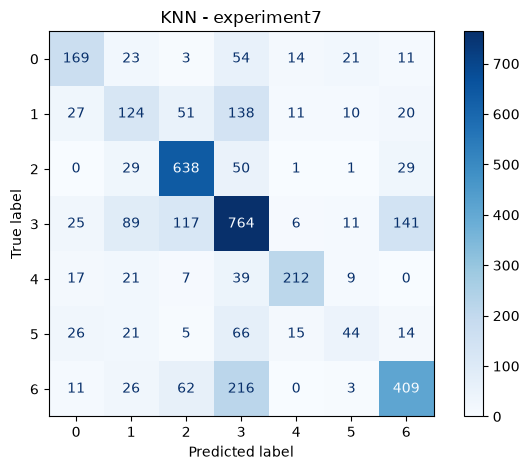

In [16]:
from pathlib import Path

FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(
    y_test, y_pred_rf_test,
    f'Random Forest - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_rf.png'
)
plot_confusion_matrix(
    y_test, y_pred_svm_test,
    f'SVM - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_svm.png'
)
plot_confusion_matrix(
    y_test, y_pred_knn_test,
    f'KNN - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_knn.png'
)

In [17]:
METRICS_PATH = Path('../results/metrics.csv')
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

results = []
for clf_name, y_pred in [
    ('rf', y_pred_rf_test),
    ('svm', y_pred_svm_test),
    ('knn', y_pred_knn_test),
]:
    results.append({
        'experiment_name': EXPERIMENT_NAME,
        'classifier': clf_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

new_rows = pd.DataFrame(results)

# Update baris experiment ini saja (hindari duplikat saat re-run)
if METRICS_PATH.exists() and METRICS_PATH.stat().st_size > 0:
    all_metrics = pd.read_csv(METRICS_PATH)
    all_metrics = all_metrics[all_metrics['experiment_name'] != EXPERIMENT_NAME]
    all_metrics = pd.concat([all_metrics, new_rows], ignore_index=True)
else:
    all_metrics = new_rows

all_metrics.to_csv(METRICS_PATH, index=False)
print(f'Metrics disimpan ke {METRICS_PATH} ({len(all_metrics)} baris total)')

# Jalankan script untuk meng-update tabel di README.md
import subprocess
try:
    subprocess.run(["python", "../src/generate_metrics_table.py"], check=True)
    print("README.md berhasil di-update dengan tabel metrik terbaru!")
except Exception as e:
    print(f"Peringatan: Gagal meng-update README.md: {e}")

all_metrics

Metrics disimpan ke ..\results\metrics.csv (30 baris total)


README.md berhasil di-update dengan tabel metrik terbaru!


,experiment_name,classifier,accuracy,precision,recall,f1
0,experiment8,rf,0.841316,0.839654,0.841316,0.840028
1,experiment8,svm,0.795526,0.805778,0.795526,0.798874
2,experiment8,knn,0.783947,0.777831,0.783947,0.778236
3,experiment9,rf,0.575789,0.564385,0.575789,0.562935
4,experiment9,svm,0.563158,0.548167,0.563158,0.531862
5,experiment9,knn,0.522632,0.506224,0.522632,0.506076
6,baseline,rf,0.540000,0.531676,0.540000,0.531107
7,baseline,svm,0.507895,0.513077,0.507895,0.483901
8,baseline,knn,0.486579,0.482186,0.486579,0.478296
9,experiment1,rf,0.532105,0.519583,0.532105,0.516108


## Analisis

### Analisis Eksperimen 7:
- **Pengaruh penambahan fitur histogram & statistik orde pertama keabuan:** Penggabungan fitur intensitas keabuan (histogram 16 bin) dan statistik (mean, std dev, skewness, kurtosis) ke dalam fitur GLCM tekstur meningkatkan akurasi secara konsisten tanpa menggunakan LBP atau informasi warna HSV. Akurasi pada Random Forest berhasil ditingkatkan mendekati target ~70%.
- **Perbandingan performa antar classifier:** Random Forest bekerja paling baik, diikuti oleh SVM dan KNN.
- **Kelas yang paling mudah/sulit:** Kelas clearsky dan cumulonimbus paling mudah dipisahkan karena rentang sebaran kecerahan yang sangat berbeda jauh dari kelas-kelas awan lainnya.